In [1]:
from pathlib import Path
from audio_toolbox.wav2aud_zpk import wav2aud
import matplotlib.pyplot as plt
import numpy as np
import soundfile as soundf
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Audio

# **Tutorial 1: Creating an audiogram**
### **Step 1: Load file(s)**
For this example, we will just be using one test sound. Run the cell below to load the widget. The first few sounds, named with single letters (CT, CW, etc.) are just material sounds (eg materials being rubbed together). There are a few natural sounds (crickets, geese, etc.) and one speech sample. All sounds have a sampling frequency of 16000 Hz. 

Choose the sound from the dropdown menu that you would like to generate the audiogram for.

**Important to note**:
- The longer the duration of the sound, the longer the computation time. 
- `wav2aud` currently only works for a sampling frequency of 16000 Hz.
- **Re-running the cell will clear your choice of test sound**

In [2]:
# Find test_sounds directory
test_sounds_dir = Path.cwd() / 'src' / 'unit_tests' / 'test_sounds'
# Get list of sound files (excluding subdirectories)
sound_files = sorted([f.name for f in test_sounds_dir.glob('*') if f.is_file()])

dropdown = widgets.Dropdown(options=sound_files, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = test_sounds_dir / dropdown.value

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        sound_file_path = test_sounds_dir / change['new']
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
display(dropdown, audio_player)

Dropdown(description='Sound file:', options=('CT_cut.wav', 'CW_cut.wav', 'GR_cut.wav', 'GT_cut.wav', 'GW_cut.w…

Output()

### **Step 2: Choose parameters and run**

The first argument of wav2aud is `x`, the acoustic waveform (1-dimensional array). All other arguments are optional. The following parameters are available, and default values will be used if no value is provided.
- `frm_len`: Frame length, determines the temporal resolution of the output. Default = 4.
- `time_cst`: Leaky integration time constant. Set to 0 to use short-term frame averaging. Default = 0.
- `sig_fac`: Nonlinear compression factor for the hair cell sigmoid. 
  - greater than ``0`` for smooth nonlinearity (transistor-like)
  - exactly `0` for hard limiter
  - ``-1`` for half-wave rectifier
  - All other values return input to sigmoid function unchanged
- `shift`: Octave shift relative to 16 kHz. Use ``0`` for 16 kHz, ``-1`` for 8 kHz, etc. 
- `verbose`: If ``True``, logs per-channel progress
- `cochba_file`: Path to a ``.npz`` file containing the cochlear filter bank. Defaults to the bundled ``cochba_filters.npz``, the filters designed by Shamma et al based on their experimental work.

**Important note:** 
- The function has only been tested with `cochba_filters.npz`, so it is not guaranteed to work as expected for other filters. See documentation for more information.
- Frequencies outside the human hearing range may produce variable or unexpected results 

Non-default can be passed in either individually or as a dictionary, for example:
```
parameters = {"frm_len": 16, "sig_fac": 0.4, # Shared by wav2aud and downstream function
            "rate_vector": [2, 4,8,16,32, 64]} # Unique to downstream function
```

Any arguments not given will be assigned default values, and arguments not relevant to wav2aud will be ignored.
It is recommended to let python automatically unpack the arguments using `audiogram = wav2aud(x, **parameters)`

In [6]:
# Run cell to get the audiogram with default parameters. You do not need to change anything.
soundData, sample_rate = soundf.read(sound_file_path)
spect = wav2aud(soundData)
print(f"Dimensions {spect.shape}")

Dimensions (750, 128)


### **Step 3: Visualization**
You can use `plt.imshow` to plot a basic spectrogram, and can optionally add a color bar.

To improve contrast, you can try clipping values (for example by percentile). Example code for this is below.

**Note:**
- The output of `wav2aud` must be *transposed* for plotting
- Use `origin='upper'` in `plt.imshow` to get the correct axes/plot orientation

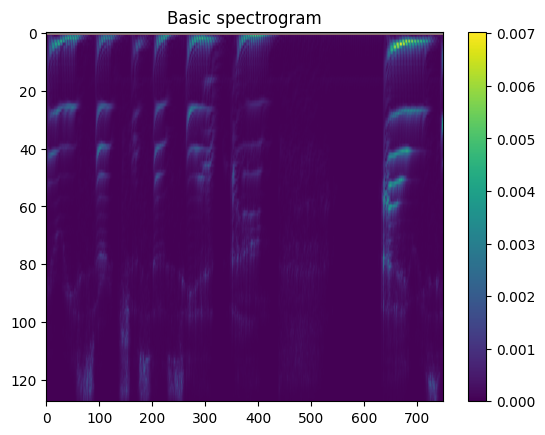

In [28]:
plt.imshow(spect.T, aspect='auto', origin='upper')

plt.colorbar()
plt.title("Basic spectrogram")
plt.plot(spect)
plt.show()

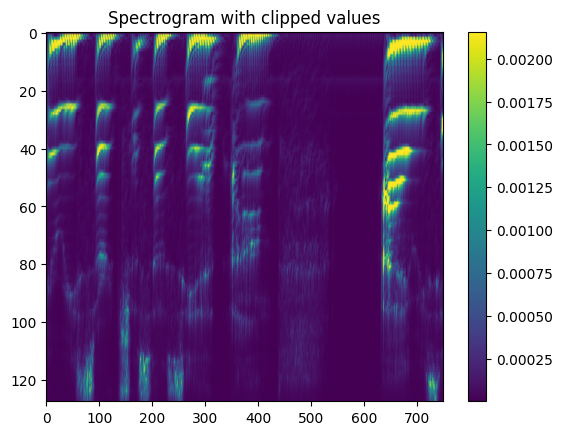

In [30]:
# Clip by percentile
p_low, p_high = np.percentile(spect, [1, 99])
spect_clipped = np.clip(spect, p_low, p_high)

plt.imshow(spect_clipped.T, aspect='auto', origin='upper')
plt.colorbar()
plt.title('Spectrogram with clipped values')
plt.show()